In [55]:
import os
import sys

import numpy as np
import pandas as pd

import warnings

warnings.filterwarnings("ignore")
sys.path.append(os.path.abspath(os.path.join("modelling", '../..')))

from utility import plot

import seaborn as sns
import matplotlib.pyplot as plt

import umap

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA, NMF, KernelPCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.manifold import TSNE

In [56]:
PLOT_DPI = 100
SEED = 42

# DATA_FILE = "../data/preprocessed_skab_dataset_fe.csv"
DATA_FILE = "../data/preprocessed_skab_dataset_train_undersampled_smote_fe.csv"

In [57]:
dataframe = pd.read_csv(DATA_FILE)

if "datetime" in dataframe.columns:
    dataframe.set_index(pd.to_datetime(dataframe.datetime), drop=True, inplace=True)
    dataframe.drop(columns=["datetime"], inplace=True)

dataframe.head()

,Unnamed: 0,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS,Electrical_Resistence,...,Temperature_Difference,Hydraulic_Power,Electrical_Power,Actual_Efficiency,Vibration_Intensity_Ratio,AccelerometerRMS_pu_Pressure,Engine_Temperature_pu_Power,Efficiency_Temperature_Difference_Ratio,anomaly,description
0,0,0.219595,0.267058,2.97205,1.074847,88.9166,28.9319,227.339,127.0000,76.492320,...,59.9847,227.509732,574.313444,0.396142,0.822275,0.000462,0.154822,0.006604,0.0,No Anomaly
1,1,0.028225,0.042124,1.43210,1.401284,68.6462,24.7640,245.677,32.9805,171.550171,...,43.8822,77.025248,299.058927,0.257559,0.670037,0.000036,0.229541,0.005869,0.0,No Anomaly
2,2,0.214053,0.259569,2.22898,1.730701,88.2787,29.6790,227.822,127.0000,102.209082,...,58.5997,366.332439,431.639079,0.848701,0.824648,0.000437,0.204520,0.014483,0.0,No Anomaly
3,3,0.255422,0.294430,2.99871,1.074847,86.2073,28.8126,232.379,126.0000,77.492989,...,57.3947,225.718316,592.311646,0.381080,0.867514,0.000597,0.145544,0.006640,0.0,No Anomaly
4,4,0.081667,0.129274,1.56118,0.733489,87.2407,22.1358,234.136,77.0000,149.973738,...,65.1049,94.131282,310.699174,0.302966,0.631739,0.000137,0.280788,0.004654,0.0,No Anomaly


In [58]:
dataframe_X = dataframe.drop(columns=["anomaly", "description"])
dataframe_y = dataframe[["anomaly"]]

dataframe_X.head()

,Unnamed: 0,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS,Electrical_Resistence,...,Specific_Power,Accelerometer_Balance,Temperature_Difference,Hydraulic_Power,Electrical_Power,Actual_Efficiency,Vibration_Intensity_Ratio,AccelerometerRMS_pu_Pressure,Engine_Temperature_pu_Power,Efficiency_Temperature_Difference_Ratio
0,0,0.219595,0.267058,2.97205,1.074847,88.9166,28.9319,227.339,127.0000,76.492320,...,5.320180,0.047463,59.9847,227.509732,574.313444,0.396142,0.822275,0.000462,0.154822,0.006604
1,1,0.028225,0.042124,1.43210,1.401284,68.6462,24.7640,245.677,32.9805,171.550171,...,10.667941,0.013899,43.8822,77.025248,299.058927,0.257559,0.670037,0.000036,0.229541,0.005869
2,2,0.214053,0.259569,2.22898,1.730701,88.2787,29.6790,227.822,127.0000,102.209082,...,3.998509,0.045516,58.5997,366.332439,431.639079,0.848701,0.824648,0.000437,0.204520,0.014483
3,3,0.255422,0.294430,2.99871,1.074847,86.2073,28.8126,232.379,126.0000,77.492989,...,5.530454,0.039008,57.3947,225.718316,592.311646,0.381080,0.867514,0.000597,0.145544,0.006640
4,4,0.081667,0.129274,1.56118,0.733489,87.2407,22.1358,234.136,77.0000,149.973738,...,4.747123,0.047607,65.1049,94.131282,310.699174,0.302966,0.631739,0.000137,0.280788,0.004654


In [59]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(dataframe_X.to_numpy())
X_scaled

array([[-1.73204531, -0.33033373, -0.31392742, ..., -0.20378837,
        -0.75943561, -0.42095824],
       [-1.73203432, -1.24497074, -1.29961635, ..., -0.23624587,
        -0.04756716, -0.6284563 ],
       [-1.73202333, -0.35682125, -0.34674521, ..., -0.20563923,
        -0.2859514 ,  1.80417313],
       ...,
       [ 1.73202333, -1.24841955, -1.3150821 , ..., -0.23620044,
         1.1873196 , -0.48979136],
       [ 1.73203432, -1.2484341 , -1.30776408, ..., -0.23632482,
         2.43291987,  0.27582701],
       [ 1.73204531, -1.24650245, -1.31056424, ..., -0.23603194,
         1.77668465, -0.28393331]], shape=(315196, 23))

In [60]:
dataframe_X_scaled = pd.DataFrame(X_scaled, columns=dataframe_X.columns)
dataframe_X_scaled = dataframe_X_scaled.assign(anomaly=dataframe.anomaly.values, description=dataframe.description.values)
dataframe_X_scaled.head()

,Unnamed: 0,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS,Electrical_Resistence,...,Temperature_Difference,Hydraulic_Power,Electrical_Power,Actual_Efficiency,Vibration_Intensity_Ratio,AccelerometerRMS_pu_Pressure,Engine_Temperature_pu_Power,Efficiency_Temperature_Difference_Ratio,anomaly,description
0,-1.732045,-0.330334,-0.313927,1.236586,-0.188610,0.725076,0.146169,-0.152574,0.654383,-0.744811,...,0.786938,0.462513,1.165554,-0.264070,0.200904,-0.203788,-0.759436,-0.420958,0.0,No Anomaly
1,-1.732034,-1.244971,-1.299616,-1.009370,1.307826,-2.237591,-1.273270,1.867961,-1.513511,0.633169,...,-2.009270,-1.171083,-0.834221,-0.945130,-1.469696,-0.236246,-0.047567,-0.628456,0.0,No Anomaly
2,-1.732023,-0.356821,-0.346745,0.152848,2.817920,0.631842,0.400604,-0.099355,0.654383,-0.372015,...,0.546432,1.969514,0.128998,1.960005,0.226947,-0.205639,-0.285951,1.804173,0.0,No Anomaly
3,-1.732012,-0.159102,-0.193980,1.275468,-0.188610,0.329092,0.105539,0.402748,0.631325,-0.730305,...,0.337183,0.443066,1.296314,-0.338090,0.697340,-0.193489,-0.847836,-0.410907,0.0,No Anomaly
4,-1.732001,-0.989547,-0.917715,-0.821112,-1.753445,0.480131,-2.168341,0.596340,-0.498513,0.320393,...,1.676064,-0.985387,-0.749653,-0.721979,-1.889965,-0.228541,0.440688,-0.971820,0.0,No Anomaly


### Principal Component Analysis (PCA)

In [61]:
pca = PCA(random_state=SEED)
X_pca = pca.fit_transform(X_scaled)

print("PCA reduced data shape:", X_pca.shape)
dataframe_pca = pd.DataFrame(X_pca, columns=[f"Principal_Component_{idx}" for idx in range(1, X_pca.shape[1]+1)])
dataframe_pca = dataframe_pca.assign(anomaly=dataframe.anomaly.values, description=dataframe.description.values)
dataframe_pca.head()

PCA reduced data shape: (315196, 23)


,Principal_Component_1,Principal_Component_2,Principal_Component_3,Principal_Component_4,Principal_Component_5,Principal_Component_6,Principal_Component_7,Principal_Component_8,Principal_Component_9,Principal_Component_10,...,Principal_Component_16,Principal_Component_17,Principal_Component_18,Principal_Component_19,Principal_Component_20,Principal_Component_21,Principal_Component_22,Principal_Component_23,anomaly,description
0,1.695040,0.529181,1.321389,-0.297517,-0.778018,-0.322191,-1.437921,-1.331014,-0.008135,-0.180009,...,0.001400,0.030280,-0.075906,0.033078,-0.005975,-0.005949,1.169764e-14,3.068476e-15,0.0,No Anomaly
1,-4.162648,0.250225,0.154440,-1.656408,0.633117,2.781445,-1.502092,-1.646887,0.816061,-0.349911,...,0.133533,-0.073689,0.057292,-0.011139,0.039684,-0.046208,3.218292e-13,1.305017e-13,0.0,No Anomaly
2,1.929660,-2.310439,-1.434435,0.142130,-2.555110,1.692376,-1.081877,-1.505574,-0.255836,-0.121379,...,-0.054945,0.008348,-0.048395,0.032016,0.005474,0.006135,-5.930589e-14,-2.048642e-14,0.0,No Anomaly
3,1.663733,0.688617,1.153955,-0.945567,-0.369681,0.130312,-1.464182,-1.152778,-0.316509,-0.563851,...,0.024497,-0.007596,0.063660,0.050024,0.032307,-0.007842,2.743953e-14,2.458005e-14,0.0,No Anomaly
4,-2.318034,0.445713,3.433806,3.401106,-0.001105,-0.109655,-2.184129,-0.674844,0.124387,-0.198979,...,-0.012851,0.081318,0.173103,0.064325,-0.020665,-0.017525,1.156437e-13,4.063616e-14,0.0,No Anomaly


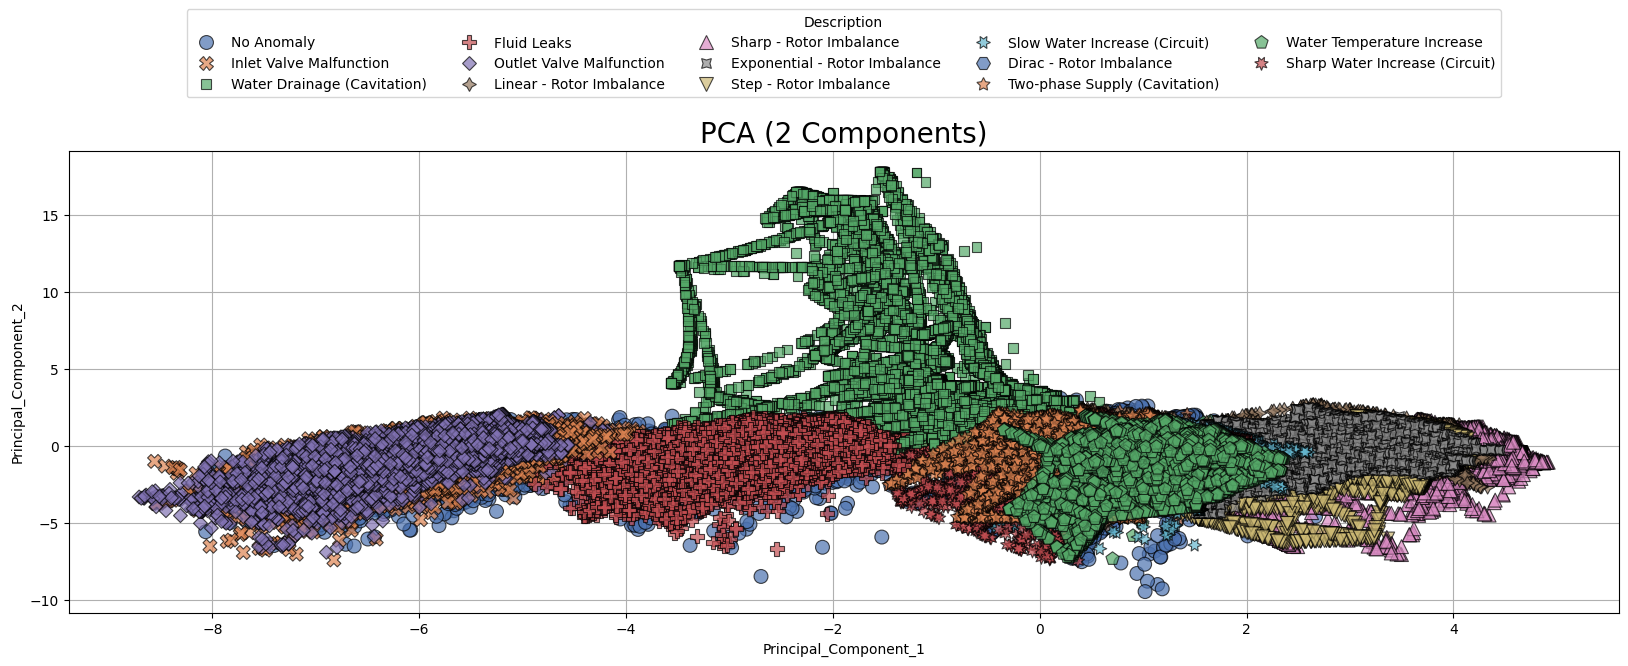

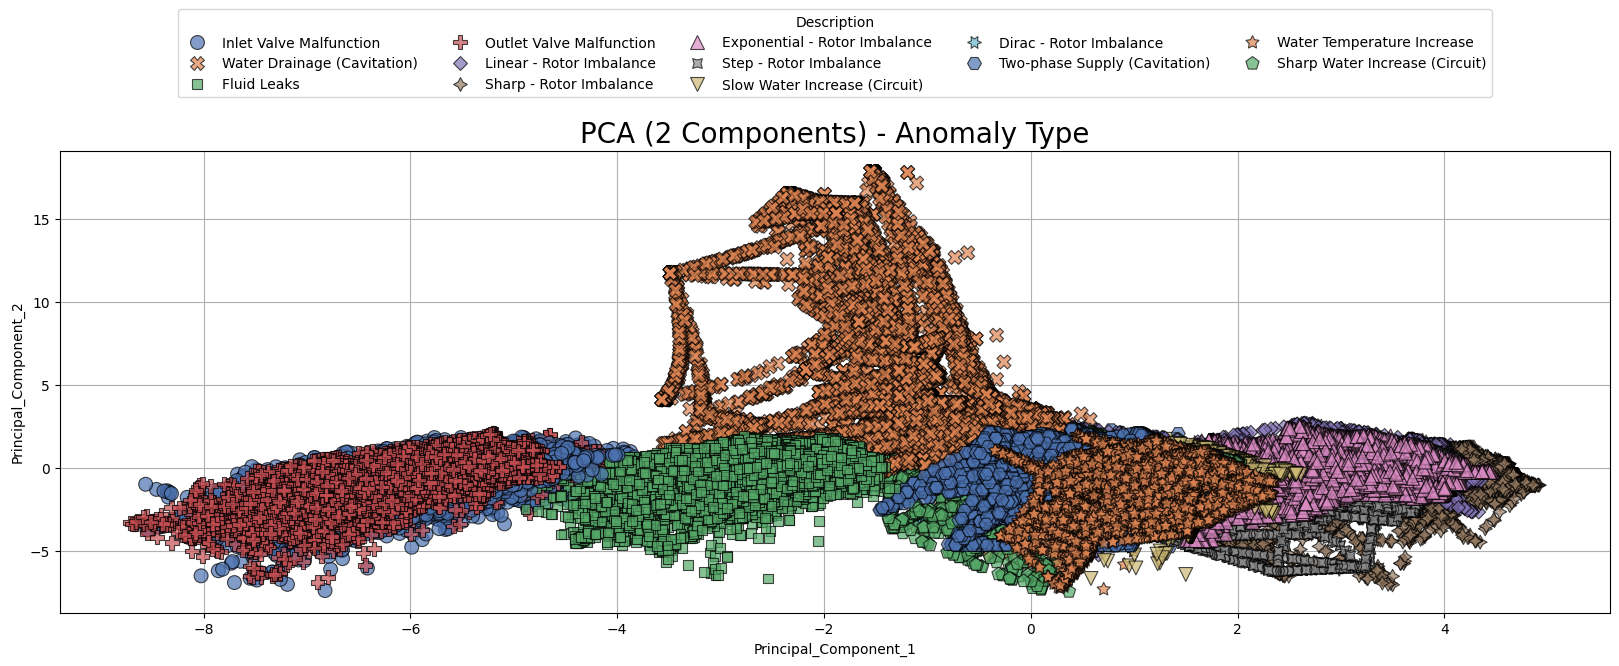

In [62]:
plot.plot_dimensional_reduction(dataframe_pca, title="PCA (2 Components)")
plot.plot_dimensional_reduction(dataframe_pca.iloc[np.where(dataframe_pca.anomaly!=0.0)], title="PCA (2 Components) - Anomaly Type")

### Linear Discriminant Analysis (LDA)

In [63]:
lda = LinearDiscriminantAnalysis()
X_lda = lda.fit_transform(X_scaled, dataframe_y.to_numpy().ravel())

print("LDA reduced data shape:", X_lda.shape)
dataframe_lda = pd.DataFrame(X_lda, columns=[f"Linear_Discriminant_{idx}" for idx in range(1, X_lda.shape[1]+1)])
dataframe_lda = dataframe_lda.assign(anomaly=dataframe.anomaly.values, description=dataframe.description.values)
dataframe_lda.head()

LDA reduced data shape: (315196, 13)


,Linear_Discriminant_1,Linear_Discriminant_2,Linear_Discriminant_3,Linear_Discriminant_4,Linear_Discriminant_5,Linear_Discriminant_6,Linear_Discriminant_7,Linear_Discriminant_8,Linear_Discriminant_9,Linear_Discriminant_10,Linear_Discriminant_11,Linear_Discriminant_12,Linear_Discriminant_13,anomaly,description
0,1.734169,-1.729186,0.000823,-2.820035,-5.014539,-2.918602,-1.560886,-0.676374,0.548885,-1.439721,-0.361195,0.646410,-0.260465,0.0,No Anomaly
1,4.598436,0.571636,0.724258,-5.631656,-2.059602,-0.960078,2.272675,3.275772,3.176631,-2.196531,2.116830,-1.703527,1.060501,0.0,No Anomaly
2,2.058125,-2.430266,-1.209159,-2.446188,-4.696153,-3.100229,-0.083196,-1.457653,0.246810,1.312989,0.325475,-0.104265,0.409058,0.0,No Anomaly
3,-0.519497,-2.207148,0.596070,-1.579658,-2.497967,-2.188385,-2.072194,-0.409286,3.681711,-0.936196,0.010975,0.097726,0.304944,0.0,No Anomaly
4,6.412331,2.050497,8.550656,5.017329,-5.015356,-1.963379,1.500003,0.563095,3.934157,-0.333853,0.023263,-0.889785,0.933998,0.0,No Anomaly


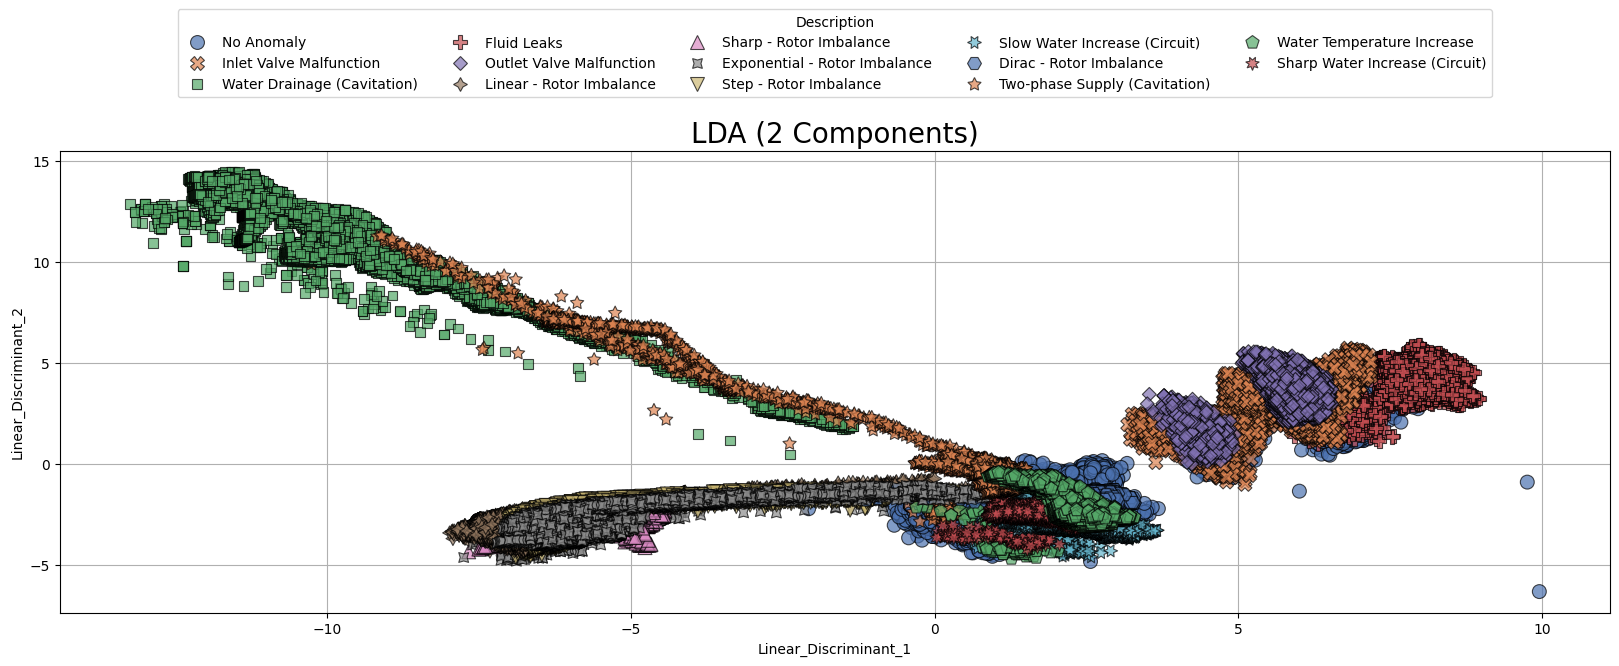

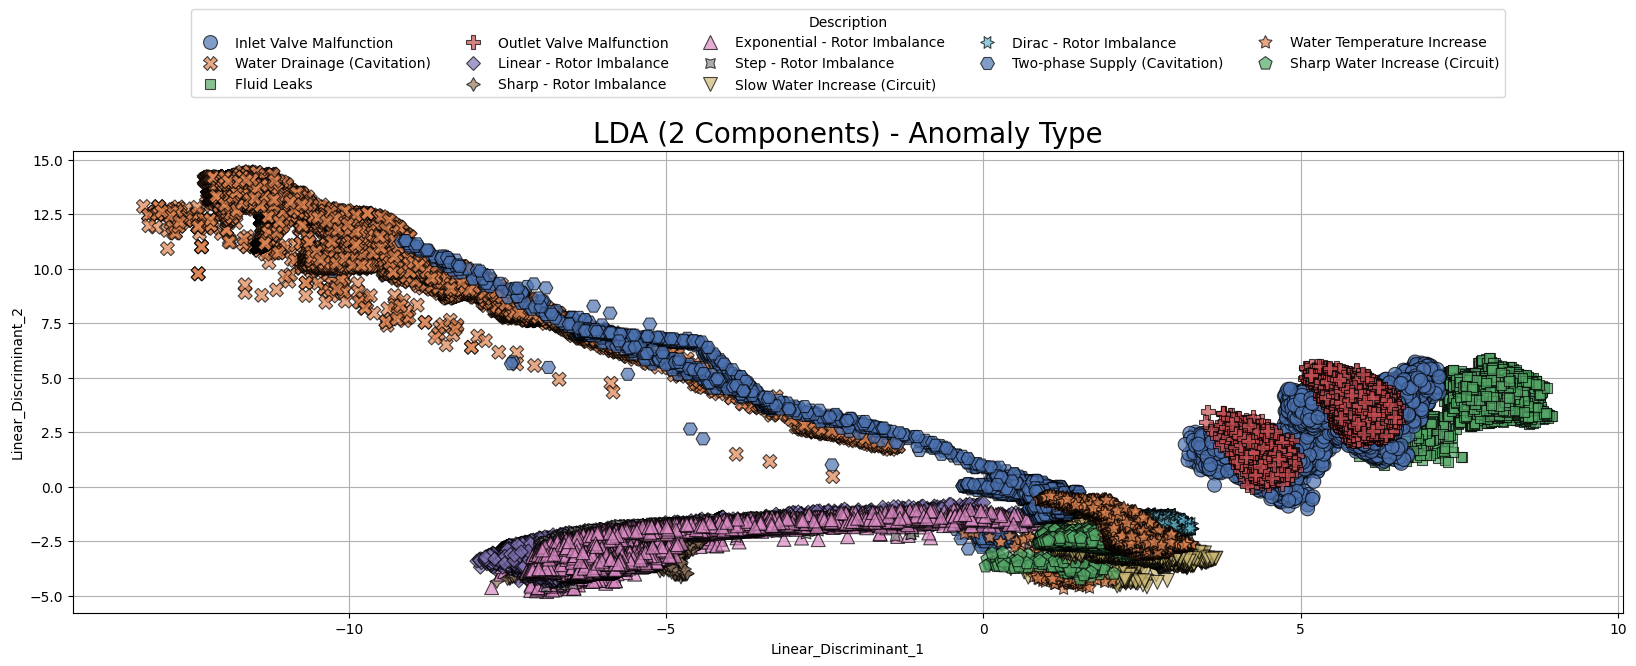

In [64]:
plot.plot_dimensional_reduction(dataframe_lda, title="LDA (2 Components)")
plot.plot_dimensional_reduction(dataframe_lda.iloc[np.where(dataframe_lda.anomaly!=0.0)], title="LDA (2 Components) - Anomaly Type")

### Non-Negative Matrix Factorization (NMF)

In [65]:
# For NMF, the input data must be non-negative.
X_nmf_positive = dataframe_X.to_numpy() - dataframe_X.to_numpy().min() # Simple way to make it non-negative for demo
nmf = NMF(n_components=None, init='random', random_state=SEED, max_iter=500)
X_nmf = nmf.fit_transform(X_nmf_positive)

print("NMF reduced data shape:", X_nmf.shape)
dataframe_nmf = pd.DataFrame(X_nmf, columns=[f"NMF_Component_{idx}" for idx in range(1, X_nmf.shape[1]+1)])
dataframe_nmf = dataframe_nmf.assign(anomaly=dataframe.anomaly.values, description=dataframe.description.values)
dataframe_nmf

NMF reduced data shape: (315196, 23)


,NMF_Component_1,NMF_Component_2,NMF_Component_3,NMF_Component_4,NMF_Component_5,NMF_Component_6,NMF_Component_7,NMF_Component_8,NMF_Component_9,NMF_Component_10,...,NMF_Component_16,NMF_Component_17,NMF_Component_18,NMF_Component_19,NMF_Component_20,NMF_Component_21,NMF_Component_22,NMF_Component_23,anomaly,description
0,0.000000,0.000000,0.000000,0.000000,0.023232,0.000000,0.000000,3.608303e-16,0.002710,0.025105,...,0.000000,0.188809,0.000000e+00,0.000000e+00,591.348621,191.694969,0.001456,0.000000,0.0,No Anomaly
1,0.000000,0.000000,0.000000,0.032988,0.000000,0.682285,0.000000,0.000000e+00,0.518006,0.000000,...,0.000000,0.035216,0.000000e+00,0.000000e+00,0.000000,120.365803,0.006029,0.000000,0.0,No Anomaly
2,0.000000,0.000000,0.000000,0.000000,0.074798,0.342814,0.000000,0.000000e+00,0.185954,0.019440,...,0.657283,0.148583,0.000000e+00,0.000000e+00,804.508119,142.040415,0.000000,0.000000,0.0,No Anomaly
3,0.000000,0.000000,0.121146,0.000000,0.024327,0.000000,0.000000,3.023789e-16,0.000000,0.024243,...,0.000000,0.173764,0.000000e+00,0.000000e+00,275.757374,201.670739,0.003052,0.000000,0.0,No Anomaly
4,0.000000,0.000000,0.726631,0.008672,0.000091,0.552579,0.000000,2.487822e-17,0.452462,0.007720,...,0.010490,0.038836,0.000000e+00,0.000000e+00,1385.830648,111.912922,0.000493,0.000000,0.0,No Anomaly
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
315191,166.839659,944.573303,0.036027,0.018532,0.000297,0.372331,0.000000,1.081078e-15,0.005830,0.010621,...,0.000000,0.000122,3.753324e-07,1.942926e-07,447.879492,77.250681,0.012313,0.000165,13.0,Outlet Valve Malfunction
315192,172.675391,952.162461,0.149994,0.010261,0.013091,0.710591,0.000000,6.124967e-15,0.021069,0.014297,...,0.013211,0.000000,3.892157e-05,0.000000e+00,266.220169,78.364007,0.001848,0.000190,13.0,Outlet Valve Malfunction
315193,178.119297,957.889910,0.012575,0.006035,0.013421,0.687831,0.000000,4.969308e-15,0.006204,0.023088,...,0.017837,0.000000,0.000000e+00,0.000000e+00,226.072165,86.530939,0.003727,0.000000,13.0,Outlet Valve Malfunction
315194,178.374198,953.514876,0.284253,0.016087,0.011023,0.540376,0.000031,7.189052e-15,0.060771,0.000000,...,0.059905,0.000000,0.000000e+00,0.000000e+00,181.130325,62.833943,0.000000,0.000000,13.0,Outlet Valve Malfunction


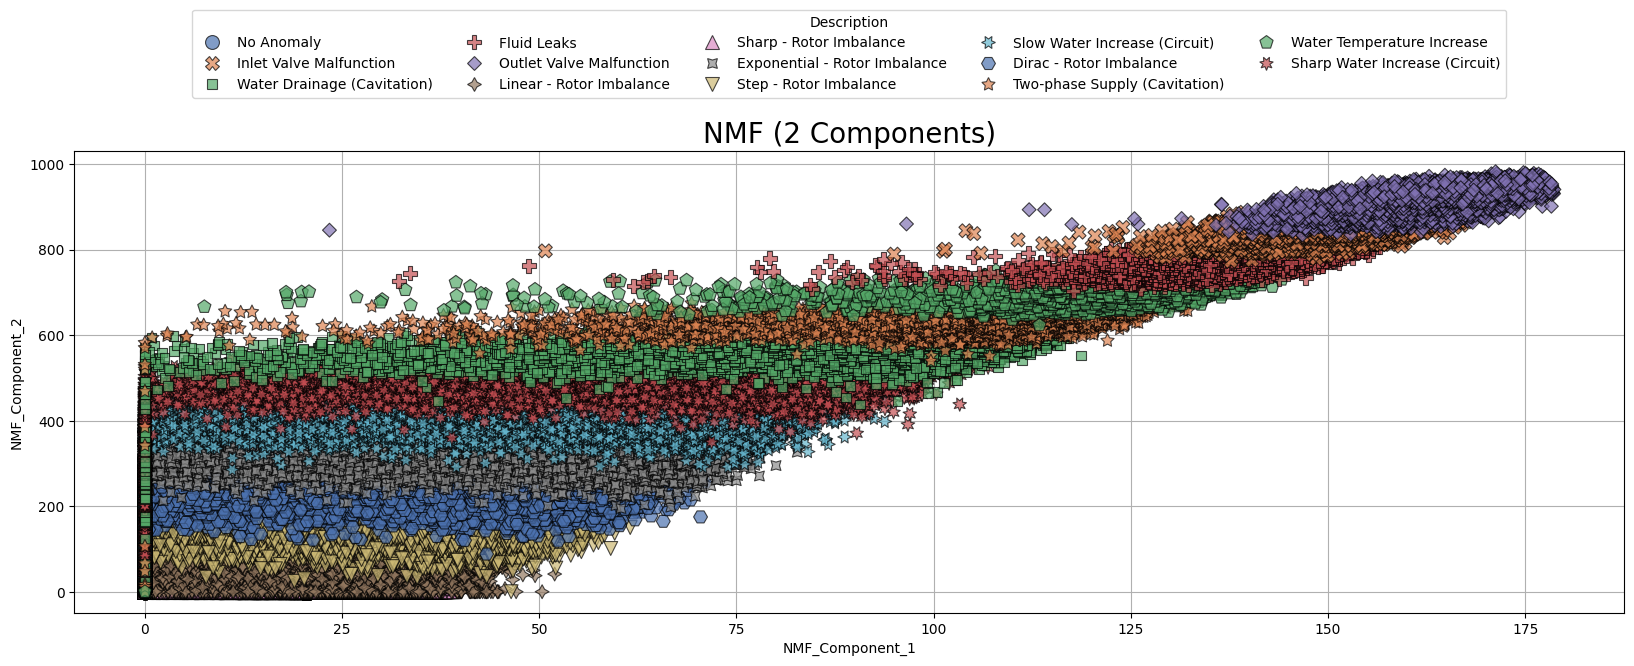

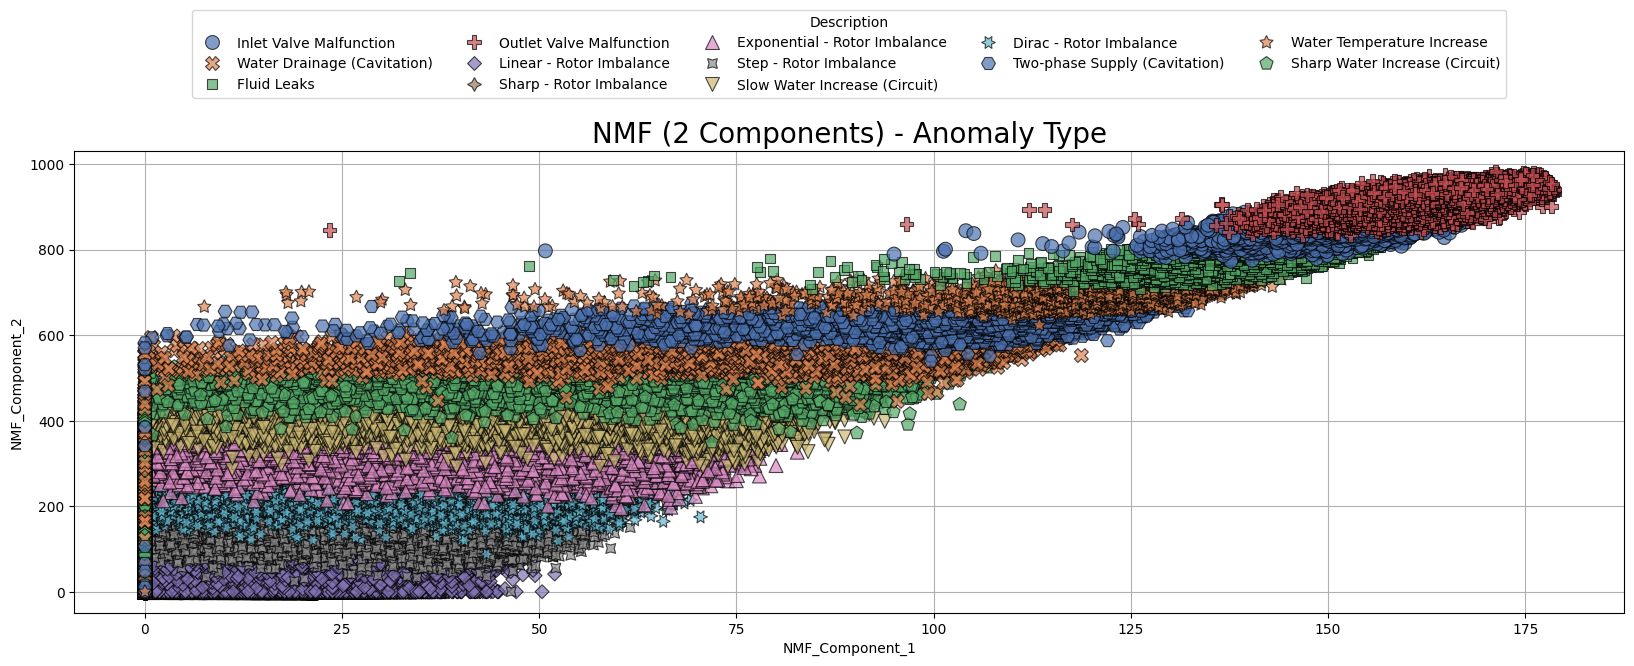

In [66]:
plot.plot_dimensional_reduction(dataframe_nmf, title="NMF (2 Components)")
plot.plot_dimensional_reduction(dataframe_nmf.iloc[np.where(dataframe_nmf.anomaly!=0.0)], title="NMF (2 Components) - Anomaly Type")

### Kernel Principal Component Analysis (KPCA)

In [68]:
# kpca = KernelPCA(n_components=5, kernel="rbf", random_state=SEED)
# X_kpca = kpca.fit_transform(X_scaled)

# print("Kernel PCA reduced data shape:", X_kpca.shape)
# dataframe_kpca = pd.DataFrame(X_kpca, columns=[f"K_Principal_Component_{idx}" for idx in range(1, X_kpca.shape[1]+1)])
# dataframe_kpca = dataframe_kpca.assign(anomaly=dataframe.anomaly.values, description=dataframe.description.values)
# dataframe_kpca

In [69]:
# plot.plot_dimensional_reduction(dataframe_kpca, title="kPCA (2 Components)")
# plot.plot_dimensional_reduction(dataframe_kpca.iloc[np.where(dataframe_kpca.anomaly!=0.0)], title="kPCA (2 Components) - Anomaly Type")

In [70]:
def get_tsne_components(dataframe, n_components=2):
    tmp = dataframe.drop(["anomaly", "description"], axis=1)
    tsne = TSNE(n_components=n_components, random_state=SEED, perplexity=50, n_jobs=5)
    X_tsne = tsne.fit_transform(tmp.values)

    print("t-SNE reduced data shape:", X_tsne.shape)
    dataframe_tsne = pd.DataFrame(X_tsne, columns=[f"tSNE_Component_{idx}" for idx in range(1, n_components+1)])
    dataframe_tsne = dataframe_tsne.assign(anomaly=dataframe.anomaly.values, description=dataframe.description.values)
    return dataframe_tsne

In [71]:
def get_umap_components(dataframe, n_components=2):
    tmp = dataframe.drop(["anomaly", "description"], axis=1)
    reducer = umap.UMAP(n_components=n_components, random_state=SEED)
    X_umap = reducer.fit_transform(tmp.values)

    print("UMAP reduced data shape:", X_umap.shape)
    dataframe_umap = pd.DataFrame(X_umap, columns=[f"UMAP_Component_{idx}" for idx in range(1, n_components+1)])
    dataframe_umap = dataframe_umap.assign(anomaly=dataframe.anomaly.values, description=dataframe.description.values)
    return dataframe_umap

In [72]:
dataframe_X_scaled_tsne = get_tsne_components(dataframe_X_scaled)

# plot.plot_dimensional_reduction(dataframe_X_scaled_tsne, title="tSNE (2 Components)")
plot.plot_dimensional_reduction(dataframe_X_scaled_tsne.iloc[np.where(dataframe_X_scaled_tsne.anomaly!=0.0)], title="tSNE (2 Components) - Anomaly Type")

dataframe_X_scaled_tsne = get_tsne_components(dataframe_lda)

# plot.plot_dimensional_reduction(dataframe_X_scaled_tsne, title="tSNE (2 Components)")
plot.plot_dimensional_reduction(dataframe_X_scaled_tsne.iloc[np.where(dataframe_X_scaled_tsne.anomaly!=0.0)], title="tSNE (2 Components) - Anomaly Type")

KeyboardInterrupt: 

UMAP reduced data shape: (31449, 2)


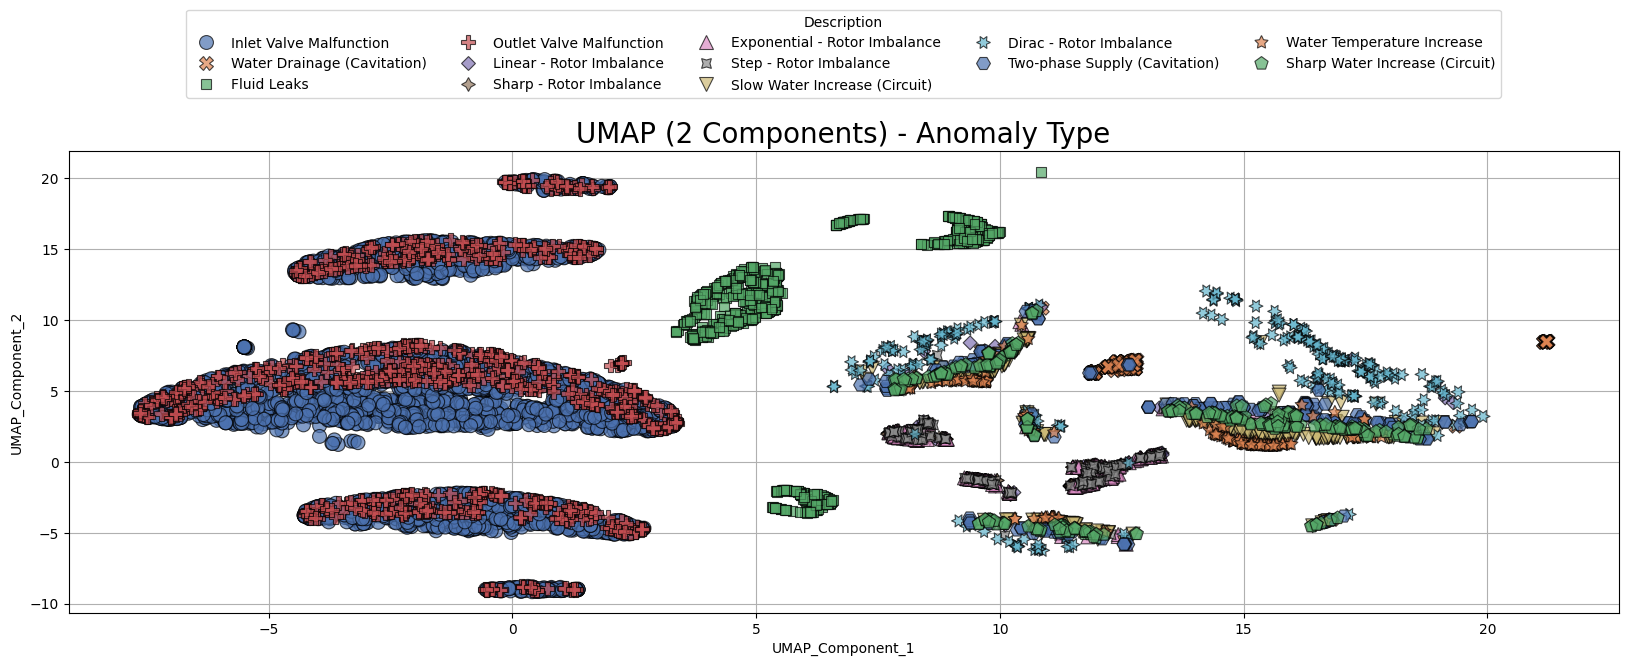

UMAP reduced data shape: (31449, 2)


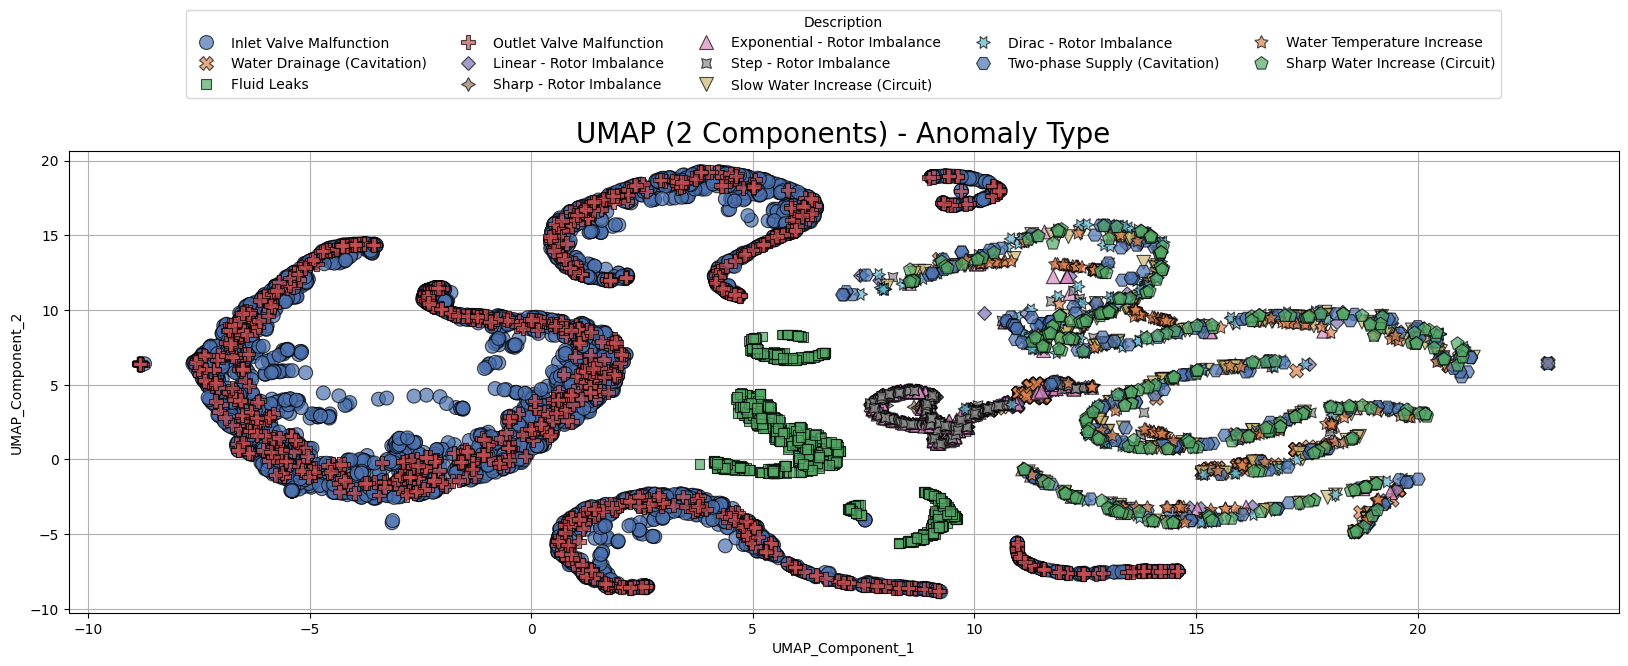

In [ ]:
dataframe_X_scaled_umap = get_umap_components(dataframe_X_scaled)

# plot.plot_dimensional_reduction(dataframe_X_scaled_umap, title="UMAP (2 Components)")
plot.plot_dimensional_reduction(dataframe_X_scaled_umap.iloc[np.where(dataframe_X_scaled_umap.anomaly!=0.0)], title="UMAP (2 Components) - Anomaly Type")

dataframe_X_scaled_umap = get_umap_components(dataframe_lda)

# plot.plot_dimensional_reduction(dataframe_X_scaled_umap, title="UMAP (2 Components)")
plot.plot_dimensional_reduction(dataframe_X_scaled_umap.iloc[np.where(dataframe_X_scaled_umap.anomaly!=0.0)], title="UMAP (2 Components) - Anomaly Type")